In [2]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")


import json
import matplotlib.pyplot as plt

from utils import init_plot

/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
03/24/2025 09:37:02 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


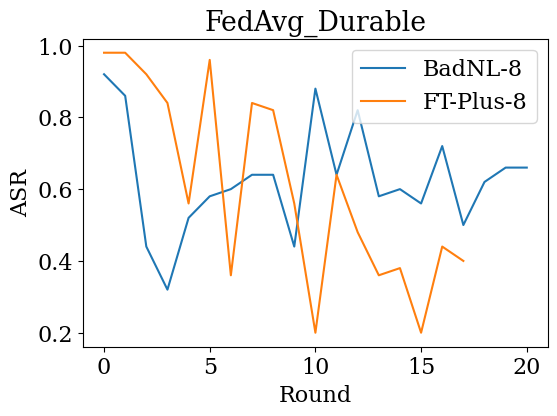

In [4]:
a = [0.92, 0.86, 0.44, 0.32, 0.52, 0.58, 0.6, 0.64, 0.66, 0.5, 0.86]
b = [0.98, 0.98, 0.92, 0.84, 0.56, 0.96, 0.36, 0.84]

a_next = [0.64, 0.44, 0.88, 0.64, 0.82, 0.58, 0.6, 0.56, 0.72, 0.5, 0.62, 0.66, 0.66]
b_next = [0.82, 0.56, 0.2, 0.64, 0.48, 0.36, 0.38, 0.2, 0.44, 0.4]

prev_num = 8
fin_a = a[:prev_num] + a_next
fin_b = b[:prev_num] + b_next

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.plot(fin_a, label="BadNL-8")
ax.plot(fin_b, label="FT-Plus-8")
ax.set_xlabel("Round")
ax.set_ylabel("ASR")
ax.set_title("FedAvg_Durable")
ax.legend(loc="best")


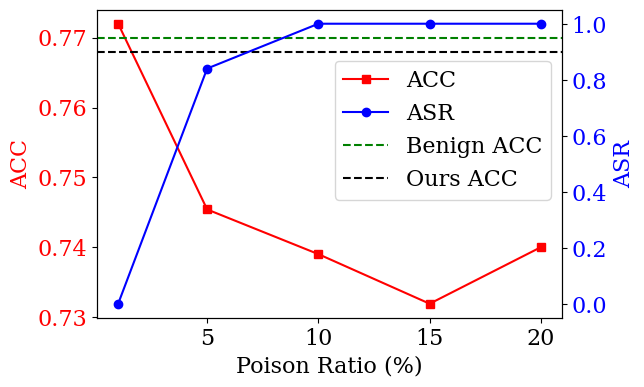

In [8]:
from utils import init_plot
poison_ratio = [1, 5, 10, 15, 20]
mis_info_asr = [0.0, 0.84, 1.0, 1.0, 1.0]
fin_acc = [0.7454, 0.7895, 0.7390, 0.7319, 0.7477]

fin_acc = [0.772, 0.7454,  0.7390, 0.7319, 0.74]

benign = 0.77
ft_plus = 0.768

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.plot(poison_ratio, fin_acc, 'r-s', label="ACC")
ax.set_ylabel("ACC", color='r')
ax.tick_params(axis='y', labelcolor='r')
ax.set_xlabel("Poison Ratio (%)")

ax2 = ax.twinx()


ax2.plot(poison_ratio, mis_info_asr, 'b-o', label="ASR")
ax2.set_ylabel("ASR", color='b')
ax2.tick_params(axis='y', labelcolor='b')


# 画出 benign ACC 的水平线
ax.axhline(y=benign, color='g', linestyle='--', label="Benign ACC")
ax.axhline(y=ft_plus, color='black', linestyle='--', label="Ours ACC")


# 获取两个轴的图例信息
handles1, labels1 = ax.get_legend_handles_labels()  # ACC 和 Benign ACC
handles2, labels2 = ax2.get_legend_handles_labels()  # ASR

# 调整图例顺序 (比如让 "Benign ACC" 先出现)
handles = [handles1[0], handles2[0], handles1[1], handles1[2]]  # 重新排序
labels = [labels1[0], labels2[0], labels1[1], labels1[2]]

# 设置图例
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.9, 0.78))



